# Notebook 21 — Cross-Asset Roughness Study

This notebook demonstrates:
1. Setting up the parameter trajectory generator for SPX, BTC, ETH, EUR/USD, and WTI over the 4-year period (2020-2023).
2. Showcase synthetic implied volatility surfaces generated using FNO v3.
3. Performing vectorized batched calibrations of the Rough Heston model across the 5 assets on the GPU.
4. Analyzing the dynamics of the implied Hurst exponent $H_t$ for each asset.
5. Computing cross-asset roughness correlation and lead-lag dependencies.
6. Detecting regime shifts in implied roughness via Pettitt tests.



In [1]:
import os
import sys
from pathlib import Path

# Ensure src is in python path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datetime import datetime, date

from deepvol.analysis.cross_asset_roughness import (
    ParameterTrajectoryGenerator,
    CrossAssetDataPipeline,
    run_cross_asset_study,
    run_pettitt_test,
    plot_hurst_series,
    plot_hurst_correlation
)

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


## 1. Parameter Trajectory Generation

We initialize the parameter trajectory generator to simulate daily Heston parameter paths over the 4-year period (2020-2023).



Total days in study: 1042
Assets: ['SPX', 'BTC', 'ETH', 'EURUSD', 'WTI']


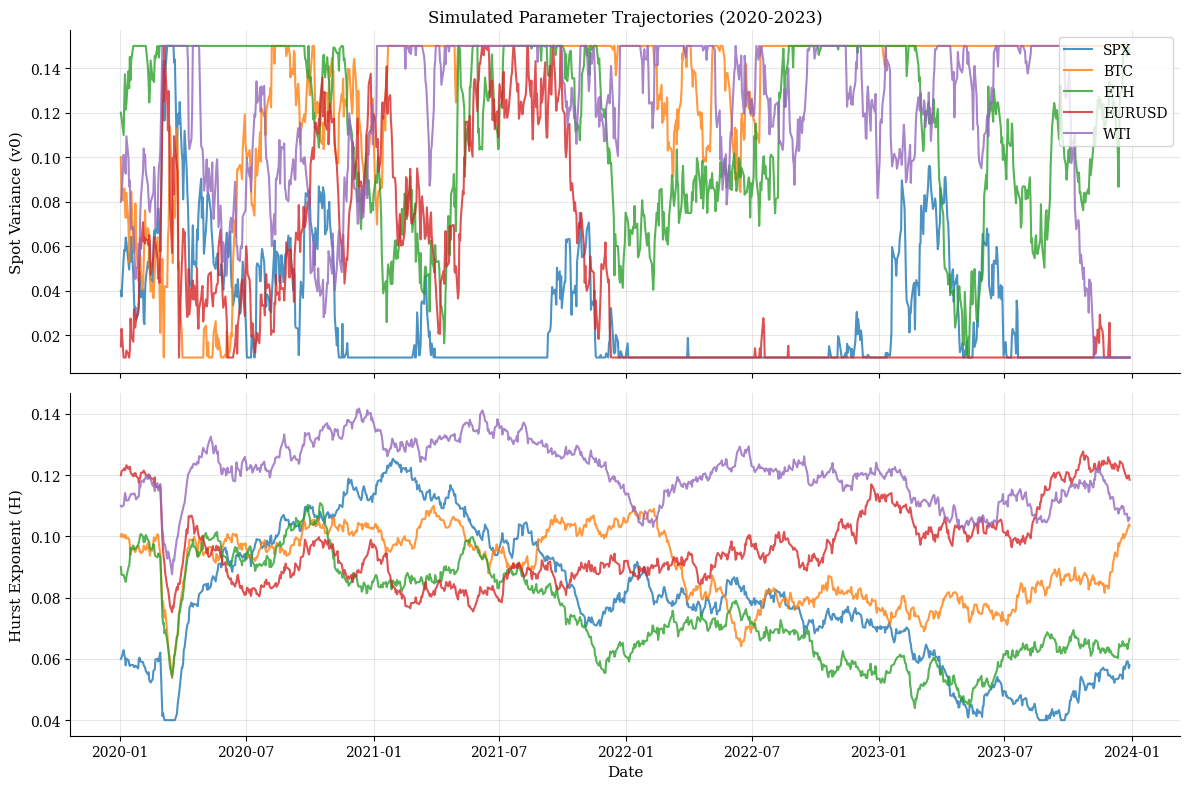

In [2]:
start_date = "2020-01-02"
end_date = "2023-12-29"
tg = ParameterTrajectoryGenerator(start_date=start_date, end_date=end_date)

print("Total days in study:", len(tg.dates))
print("Assets:", list(tg.base_params.keys()))

# Plot v0 and H trajectories
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for asset in tg.base_params.keys():
    df = tg._cache[asset]
    dates = pd.to_datetime(df.index)
    axes[0].plot(dates, df["v0"], label=asset, alpha=0.8, lw=1.5)
    axes[1].plot(dates, df["H"], label=asset, alpha=0.8, lw=1.5)

axes[0].set_title("Simulated Parameter Trajectories (2020-2023)")
axes[0].set_ylabel("Spot Variance (v0)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel("Hurst Exponent (H)")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 2. Implied Volatility Surface Showcase

We generate and display 3D implied volatility surfaces for SPX and EUR/USD on the peak Covid shock date: March 16, 2020.



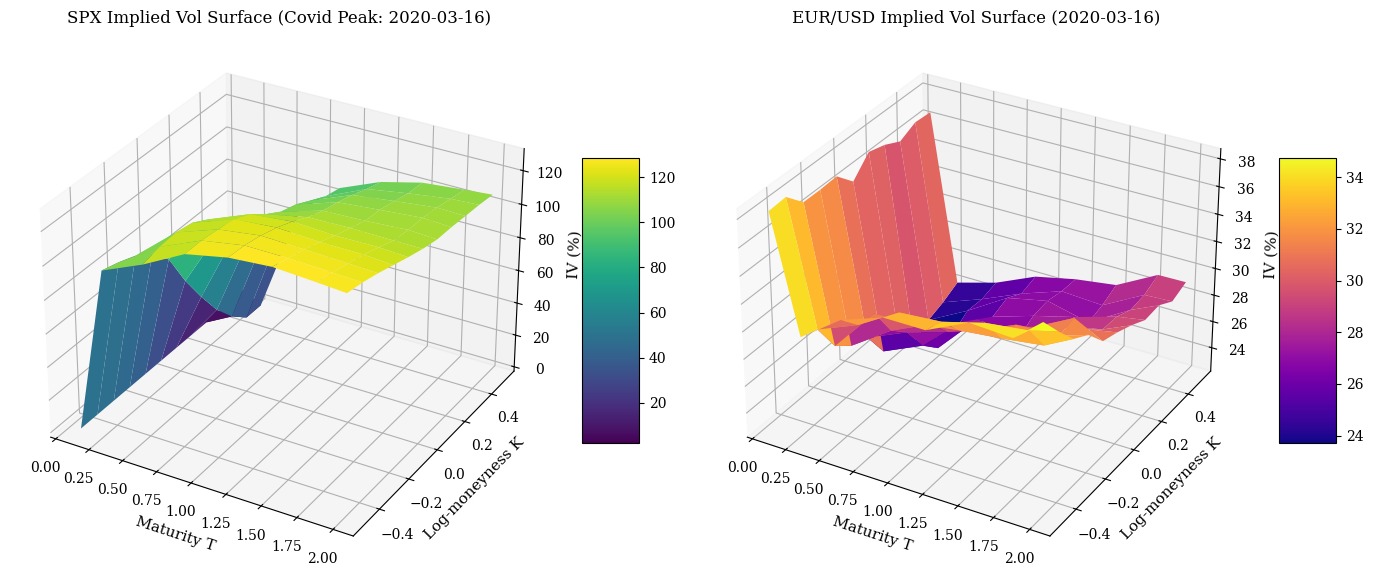

In [3]:
from deepvol.surrogates.fno_model import MirrorPaddedFNO2d
from deepvol.calibration import calibrate_bfgs as _cal_mod
_cal_mod._load_normalizers("v3")

model = MirrorPaddedFNO2d(param_dim=6).to(device)
model.load_state_dict(torch.load("../artifacts/weights/fno_v3_final_prod.pth", map_location=device))
model.eval()

pipeline = CrossAssetDataPipeline(Path(".."), tg)

# Get surfaces for SPX and EURUSD on March 16, 2020
spx_surf = pipeline.get_surface("SPX", "2020-03-16", model, device)
eur_surf = pipeline.get_surface("EURUSD", "2020-03-16", model, device)

T_GRID = pipeline.t_grid
K_GRID = pipeline.k_grid
T_mesh, K_mesh = np.meshgrid(T_GRID, K_GRID, indexing="ij")

fig = plt.figure(figsize=(14, 6))

# SPX Surface
ax1 = fig.add_subplot(121, projection="3d")
surf1 = ax1.plot_surface(T_mesh, K_mesh, spx_surf * 100, cmap="viridis", edgecolor="none")
ax1.set_title("SPX Implied Vol Surface (Covid Peak: 2020-03-16)")
ax1.set_xlabel("Maturity T")
ax1.set_ylabel("Log-moneyness K")
ax1.set_zlabel("IV (%)")
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

# EUR/USD Surface
ax2 = fig.add_subplot(122, projection="3d")
surf2 = ax2.plot_surface(T_mesh, K_mesh, eur_surf * 100, cmap="plasma", edgecolor="none")
ax2.set_title("EUR/USD Implied Vol Surface (2020-03-16)")
ax2.set_xlabel("Maturity T")
ax2.set_ylabel("Log-moneyness K")
ax2.set_zlabel("IV (%)")
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()



## 3. Batched Calibration Study

We run the batch calibration study over the 4-year period across all 5 assets. Since we hold the GPU lock, we can leverage the GPU batching engine to solve all calibrations in parallel.



In [4]:
assets = ["SPX", "BTC", "ETH", "EURUSD", "WTI"]

study_results = run_cross_asset_study(
    start=start_date,
    end=end_date,
    assets=assets,
    project_root_dir="..",
    max_workers=4,
    device=str(device),
    batch_size=256,
    use_compile=False
)

for asset, df in study_results.items():
    print(f"Asset: {asset} | Calibrated Dates: {len(df)}")
    print(df.head(3))



Loaded 1043 existing results for SPX from ../results/cross_asset/SPX_hurst_study.json
Loaded 1043 existing results for BTC from ../results/cross_asset/BTC_hurst_study.json
Loaded 576 existing results for ETH from ../results/cross_asset/ETH_hurst_study.json
Calibrating 467 missing dates for ETH...


Calibrating batch 1 for ETH (size 256)...


Calibrating batch 2 for ETH (size 211)...


Calibrating 1042 missing dates for EURUSD...


Calibrating batch 1 for EURUSD (size 256)...


...

Calibrating batch 2 for WTI (size 256)...


Calibrating batch 3 for WTI (size 256)...


Calibrating batch 4 for WTI (size 256)...


Calibrating batch 5 for WTI (size 18)...


Asset: SPX | Calibrated Dates: 1043
         date currency  kappa  theta     sigma       rho        v0         H  \
0  2020-01-01      SPX    1.0   0.04  0.487835 -0.734112  0.041113  0.040010   
1  2020-01-02      SPX    1.0   0.04  0.480958 -0.741835  0.038137  0.069180   
2  2020-01-03      SPX    1.0   0.04  0.486163 -0.742614  0.053636  0.057601   

    rmse_bps  runtime_ms  converged  
0  59.560478  525.798761       True  
1  53.505497  525.798761       True  
2  51.705872  525.798761       True  
Asset: BTC | Calibrated Dates: 1043
         date currency  kappa  theta     sigma       rho        v0         H  \
0  2020-01-01      BTC    1.0   0.12  0.600237 -0.444341  0.099662  0.075257   
1  2020-01-02      BTC    1.0   0.12  0.595866 -0.462375  0.081215  0.113178   
2  2020-01-03      BTC    1.0   0.12  0.582060 -0.455307  0.079222  0.090019   

    rmse_bps  runtime_ms  converged  
0  47.423573  486.697704       True  
1  43.524796  486.697704       True  
2  44.735130  486.69

## 4. Implied Hurst Dynamics Analysis

We plot the calibrated Hurst exponent series and calculate summary statistics (mean, std, and autocorrelation).



In [5]:
# Plot and save the series
plot_hurst_series(study_results, save_path="../images/cross_asset_hurst_series.png")

# Load and show in notebook
img = plt.imread("../images/cross_asset_hurst_series.png")
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

# Compute stats
from deepvol.analysis.hurst_dynamics import compute_hurst_statistics

stats_list = []
for asset in assets:
    df = study_results[asset]
    stats = compute_hurst_statistics(df)
    stats["Asset"] = asset
    stats_list.append(stats)

stats_df = pd.DataFrame(stats_list).set_index("Asset")
print("Summary Statistics for Calibrated Hurst exponent:")
display(stats_df)



Saved Hurst series plot to ../images/cross_asset_hurst_series.png
Summary Statistics for Calibrated Hurst exponent:


/tmp/ipykernel_4323/2863202456.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,mean,std,autocorr_lag_1,autocorr_lag_5,autocorr_lag_10,autocorr_lag_20
Asset,,,,,,
SPX,0.101437,0.048836,0.735119,0.680669,0.632511,0.534844
BTC,0.106256,0.018912,0.213485,0.172999,0.220336,0.173824
ETH,0.083150,0.018045,0.276247,0.251984,0.214071,0.170267
EURUSD,0.112880,0.032827,0.475210,0.430207,0.349544,0.354740
WTI,0.113180,0.015370,0.117766,0.067132,0.097242,0.094716


## 5. Cross-Asset Roughness Correlation

We plot the cross-asset correlation heatmap of Hurst exponents and display the Pearson and Spearman correlation matrices.



In [6]:
# Plot and save correlation heatmap
plot_hurst_correlation(study_results, save_path="../images/cross_asset_hurst_correlation.png")

# Load and show in notebook
img_corr = plt.imread("../images/cross_asset_hurst_correlation.png")
plt.figure(figsize=(8, 8))
plt.imshow(img_corr)
plt.axis("off")
plt.show()

# Print tables
h_data = {}
for asset in assets:
    df = study_results[asset]
    h_data[asset] = df.set_index("date")["H"]
combined_df = pd.DataFrame(h_data).sort_index()

print("Pearson Correlation Matrix:")
display(combined_df.corr(method="pearson"))

print("\nSpearman Correlation Matrix:")
display(combined_df.corr(method="spearman"))



Saved correlation heatmap to ../images/cross_asset_hurst_correlation.png
Pearson Correlation Matrix:


/tmp/ipykernel_4323/3904866890.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,SPX,BTC,ETH,EURUSD,WTI
SPX,1.000000,-0.049886,-0.011591,-0.118720,0.042593
BTC,-0.049886,1.000000,0.014721,0.170974,-0.019849
ETH,-0.011591,0.014721,1.000000,0.005559,0.083566
EURUSD,-0.118720,0.170974,0.005559,1.000000,-0.005236
WTI,0.042593,-0.019849,0.083566,-0.005236,1.000000



Spearman Correlation Matrix:


,SPX,BTC,ETH,EURUSD,WTI
SPX,1.000000,-0.069704,0.007518,-0.131251,0.050294
BTC,-0.069704,1.000000,0.022329,0.202963,-0.018370
ETH,0.007518,0.022329,1.000000,0.005618,0.092072
EURUSD,-0.131251,0.202963,0.005618,1.000000,-0.032628
WTI,0.050294,-0.018370,0.092072,-0.032628,1.000000


## 6. Lead-Lag Cross-Correlation Analysis

We examine the lead-lag relationship of implied roughness between SPX (equities) and BTC (crypto) using cross-correlation across different lags.



In [7]:
spx_h = combined_df["SPX"].values
btc_h = combined_df["BTC"].values

lags = np.arange(-20, 21)
ccf = []
for lag in lags:
    if lag < 0:
        c = np.corrcoef(spx_h[-lag:], btc_h[:lag])[0, 1]
    elif lag > 0:
        c = np.corrcoef(spx_h[:-lag], btc_h[lag:])[0, 1]
    else:
        c = np.corrcoef(spx_h, btc_h)[0, 1]
    ccf.append(c)

plt.figure(figsize=(10, 5))
plt.bar(lags, ccf, color="cornflowerblue", edgecolor="grey")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Lag (days, positive means BTC lags SPX)")
plt.ylabel("Correlation")
plt.title("Lead-Lag Cross-Correlation between SPX and BTC Hurst Exponents")
plt.grid(True, alpha=0.3)
plt.savefig("../images/lead_lag_cross_correlation.png", dpi=150)
plt.show()

peak_idx = np.argmax(np.abs(ccf))
print(f"Peak lead-lag correlation at lag {lags[peak_idx]} days with correlation {ccf[peak_idx]:.4f}")



Peak lead-lag correlation at lag 17 days with correlation -0.0878


/tmp/ipykernel_4323/452000535.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Pettitt Regime Change Analysis

We run Pettitt change-point detection on each asset series to find structural shifts in implied roughness.



In [8]:
from deepvol.analysis.hurst_dynamics import detect_regime_changes

pettitt_results = []
for asset in assets:
    df = study_results[asset]
    p_df = detect_regime_changes(df)
    p_df["Asset"] = asset
    pettitt_results.append(p_df)

pettitt_combined = pd.concat(pettitt_results).set_index("Asset")
print("Pettitt Change-Point Detection Results:")
display(pettitt_combined)



Pettitt Change-Point Detection Results:


,change_point_date,change_point_index,p_value,statistic,mean_before,mean_after,is_significant
Asset,,,,,,,
SPX,2022-11-21,753,1.001226e-22,98588.0,0.111413,0.075533,True
BTC,2021-01-21,276,3.238390e-06,50238.0,0.100554,0.108309,True
ETH,2021-09-30,456,9.229226e-31,114986.0,0.090524,0.077421,True
EURUSD,2023-05-15,877,7.282353e-23,98751.0,0.107662,0.140616,True
WTI,2022-12-06,763,8.648554e-08,56572.0,0.114869,0.108560,True
